In [43]:
from summarize_utils import SummarizePlotter

original_path = "./datasets_parquet/bigdata-pw/Flickr/bigdata_pw_Flickr.parquet"
compressed_path = "./datasets_compress/bigdata-pw/Flickr/bigdata_pw_Flickr.parquet"

flicker_plotter = SummarizePlotter(original_path, compressed_path, "Flicker Datasets")
flicker_plotter.add_target_column(
    "url_sq",
    "url_prefix || 's' || url_suffix",
    "LENGTH(url_prefix) + 1 + 4"
)
flicker_plotter.add_target_column(
    "id",
    "SUBSTR(url_prefix, id_offset + 1, id_len)",
    "id_len"
)



Added target column: url_sq
Added target column: id


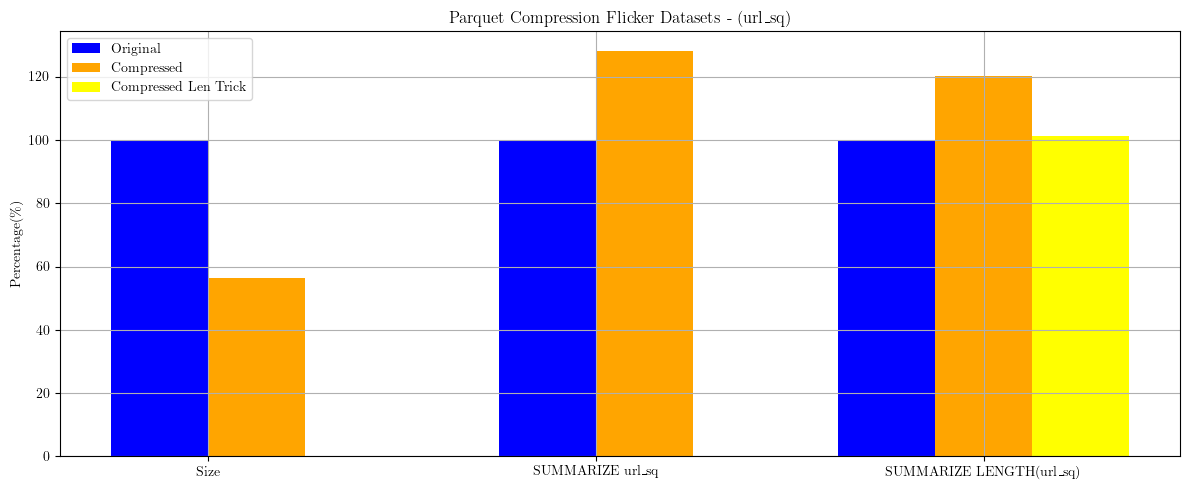

In [44]:
flicker_plotter.plot_target_column("url_sq")

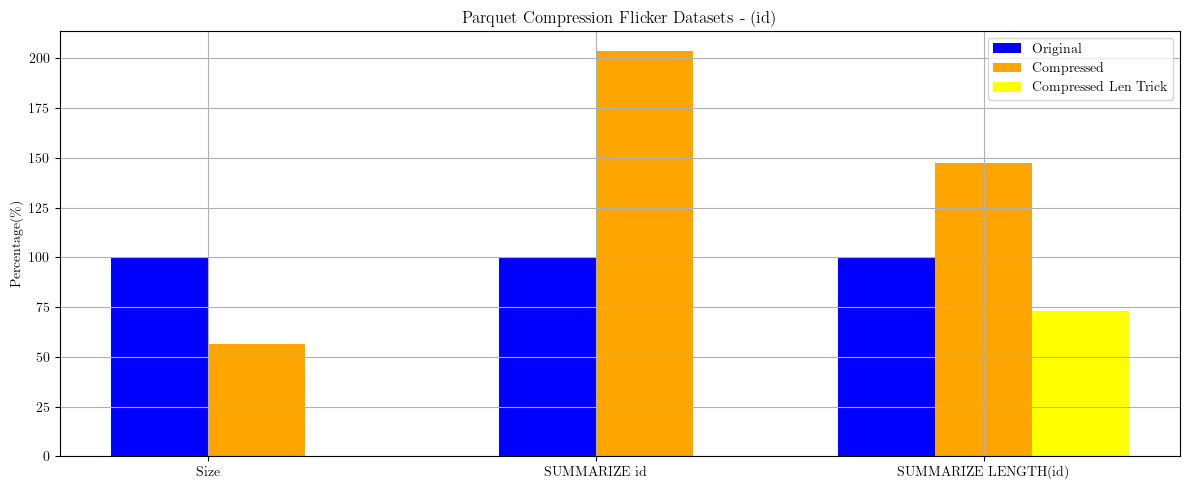

In [45]:
flicker_plotter.plot_target_column("id")

In [ ]:
import pandas as pd 
import duckdb

df = pd.read_parquet(original_path)
con = duckdb.connect()
con.register("df", df)
# get the column names by sql
column_names = con.execute("SELECT * FROM df LIMIT 0").df().columns.tolist()
print(column_names)

In [ ]:
remove_columns = ['id', 'url_sq', 'url_q', 'url_t', 'url_s', 'url_n', 'url_w', 'url_m', 'url_z', 'url_c', 'url_l']
sql = "SUBSTR(url_sq, 1, LENGTH(url_sq) - 6) AS url_prefix, SUBSTR(url_sq, LENGTH(url_sq) - 4) AS url_suffix, LENGTH(id) AS id_len, POSITION(id IN url_sq) - 1 AS id_offset"

for column in column_names:
    if column not in remove_columns:
        if len(sql) == 0:
            sql = f'{column}'
        else:
            sql += f', {column}'

# sql = 'SUBSTR(url_sq, 1, LENGTH(url_sq) - 6) AS url_prefix, SUBSTR(url_sq, LENGTH(url_sq) - 4) AS url_suffix, url_sq'

sql = f'SELECT {sql} FROM df'
# print(sql)
compress_df = con.execute(sql).df()
# con.register("compress_df", compress_df)
# decompress_df = con.execute("SELECT SUBSTR(url_prefix, id_offset + 1, id_len) AS id FROM compress_df LIMIT 11").df()
# print(compress_df.iloc[10]['url_prefix'])
# print(compress_df.iloc[10]['url_suffix'])
# print(compress_df.iloc[10]['id_offset'])
# print(compress_df.iloc[10]['id_len'])

# print(decompress_df.iloc[10]['id'])

In [ ]:
from utils import write_parquet
write_parquet(compress_df, compressed_path)